# Amazon review NLP

## 1 Prepare environment

In [1]:
# Data loading
import json
import pandas as pd
import ast

In [2]:
# General processing
from tqdm import tqdm
tqdm.pandas()
from IPython.display import clear_output

In [3]:
# NLP
import re
import nltk
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer
from nltk.sentiment.vader import SentimentIntensityAnalyzer
from afinn import Afinn
from bertopic import BERTopic

In [4]:
# Analysis
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import spearmanr
from wordcloud import WordCloud

## 2 Dataset

### 2.0 Back up / read in backed-up data

### 2.1 Explore raw data

In [5]:
# See how many lines are in the dataset
json_lines = 0

with open('.data/Office_Products.jsonl', 'r') as fp:
    for line in fp:
        json_lines = json_lines + 1

In [6]:
# See how data is structured in the dataset
with open('.data/Office_Products.jsonl', 'r') as fp:
    for line in fp:
        test_dict = json.loads(line)
        break

test_dict

{'rating': 5.0,
 'title': 'Pretty & I love it!',
 'text': 'Lovely ink. Writes well. The right amount of wet/dry. Currently using it in both a platinum curidas (f) & a pelican twist (m) & it writes well in both.  Beautiful color & flows nicely. It has not clogged up my nibs.',
 'images': [],
 'asin': 'B01AHHL4X2',
 'parent_asin': 'B01MZ3SD2X',
 'user_id': 'AFKZENTNBQ7A7V7UXW5JJI6UGRYQ',
 'timestamp': 1677939345945,
 'helpful_vote': 0,
 'verified_purchase': True}

In [7]:
# Choose columns of interest
cols = ['rating', 'text', 'asin']

### 2.2 Read in raw data

In [8]:
# Set up lists for batches
intermediate_batch = []
max_batch_size = 100000
intermediate_dfs = []

# Read in data batch-wise
with open('.data/Office_Products.jsonl', 'r') as f:
    for line in tqdm(f, total=json_lines):
        r = json.loads(line)
        intermediate_batch.append({c: r.get(c) for c in cols})
        if len(intermediate_batch) == max_batch_size:
            intermediate_dfs.append(pd.DataFrame(intermediate_batch))
            intermediate_batch.clear()
clear_output()

# Add final non-full batch
if len(intermediate_batch) != 0:
    intermediate_dfs.append(pd.DataFrame(intermediate_batch))
    intermediate_batch.clear()

# Append batches
raw_reviews = pd.concat(intermediate_dfs, ignore_index=True)
intermediate_dfs.clear()

### 2.3 Explore raw data

In [9]:
# Info
raw_reviews.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12845712 entries, 0 to 12845711
Data columns (total 3 columns):
 #   Column  Dtype  
---  ------  -----  
 0   rating  float64
 1   text    object 
 2   asin    object 
dtypes: float64(1), object(2)
memory usage: 294.0+ MB


In [10]:
# Top 5 reviews
raw_reviews.head()

,rating,text,asin
0,5.0,Lovely ink. Writes well. The right amount of w...,B01AHHL4X2
1,4.0,Overall I’m pretty happy with this purchase bc...,B08L6H23JZ
2,1.0,[[VIDEOID:63276c19932aa4f3687042b8b9f8613c]] U...,B07JDZ5J46
3,4.0,"It’s a beautiful color, but even though it had...",B004MNX7EW
4,3.0,Idk if I just got a bad batch which is possibl...,B019YLRFFS


In [11]:
# Reviews containing nas
raw_reviews[raw_reviews.isna().any(axis=1)]

,rating,text,asin


## 3 Clean data

### 3.1 Clean ratings

<Axes: xlabel='rating'>

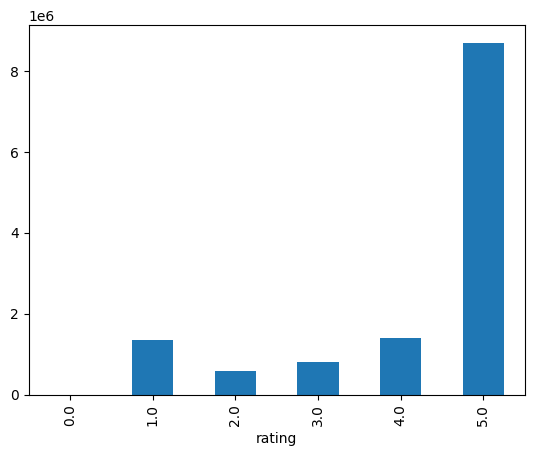

In [12]:
# Observe ratings
raw_reviews['rating'].value_counts().sort_index().plot.bar()

In [13]:
# Remove erroneous reviews
raw_reviews = raw_reviews.loc[raw_reviews['rating'] != 0.0]

In [14]:
# Normalise ratings around -1 to 1
raw_reviews['normalised_rating'] = (raw_reviews['rating'] - 3 ) / 2

In [15]:
# Classify rating
def rating_classification(score):
    if score > 0:
        return 'Positive'
    elif score < 0:
        return 'Negative'
    else:
        return 'Neutral'

raw_reviews['rating_classification'] = raw_reviews['normalised_rating'].progress_apply(rating_classification)
clear_output()

<Axes: ylabel='count'>

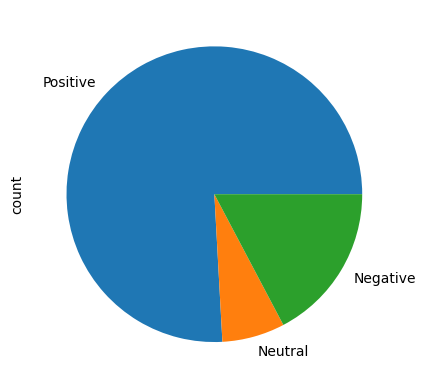

In [108]:
raw_reviews['rating_classification'].value_counts().sort_index(ascending=False).plot.pie()

In [128]:
raw_reviews['rating_classification'].value_counts() / sum(raw_reviews['rating_classification'].value_counts())

rating_classification
Positive    0.758686
Negative    0.172702
Neutral     0.068612
Name: count, dtype: float64

### 3.2 Clean text

In [ ]:
# Reviews containing non-alphanumeric characters (printing because text is often long)
i = 0
for index, text in raw_reviews.loc[raw_reviews['text'].str.contains(r'[^a-zA-Z0-9\s]'), 'text'].items():
    if i == 10:
        break
    print(text)
    i = i + 1

#### 3.2.1 Embedded references

In [17]:
# Remove text contained by and including '[[' and ']]'
raw_reviews['text'] = raw_reviews['text'].str.replace(r'\[\[.*?\]\]', '', regex=True)

#### 3.2.2 HTML code

In [18]:
# Remove text contained by and including '<' and '>'
raw_reviews['text'] = raw_reviews['text'].str.replace(r'\<.*?\>', '', regex=True)

#### 3.2.3 Links

In [ ]:
# Reviews with links
i = 0
for index, text in raw_reviews.loc[raw_reviews['text'].str.contains(r'https?://\S+|www\.\S+'), 'text'].items():
    if i == 10:
        break
    print(text)
    i = i + 1

In [20]:
# Remove links from reviews
raw_reviews['text'] = raw_reviews['text'].str.replace(r'https?://\S+|www\.\S+', '', regex=True)

#### 3.2.4 No letters

In [ ]:
# Reviews not containing letters (no need to print)
raw_reviews.loc[raw_reviews['text'].str.contains(r'^[^a-zA-Z]*$'), 'text'].value_counts()

In [22]:
# Remove reviews not containing letters
raw_reviews = raw_reviews.loc[~raw_reviews['text'].str.contains(r'^[^a-zA-Z]*$')]

### 3.3 Product-level cleaning

In [23]:
# Count of review classification by product
rating_classification_product_counts = raw_reviews.groupby(['asin', 'rating_classification']).size().unstack(fill_value=0)

In [24]:
# Remove reviews of products with fewer than 10 of each type of review
valid_asins = rating_classification_product_counts[(rating_classification_product_counts >= 10).all(axis=1)].index
raw_reviews = raw_reviews[raw_reviews['asin'].isin(valid_asins)]

array([[<Axes: title={'center': 'normalised_rating'}>]], dtype=object)

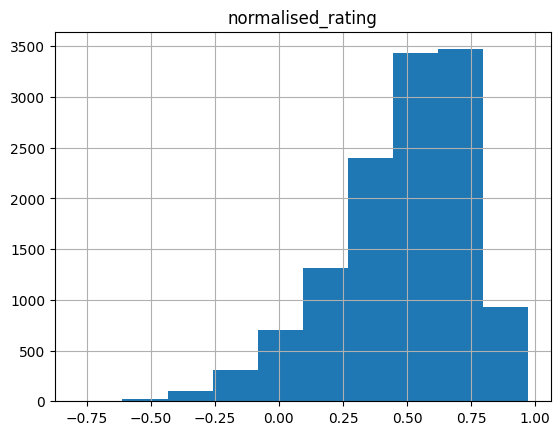

In [116]:
# Distribution of mean reviews by product
mean_ratings = raw_reviews[['asin', 'normalised_rating']].groupby('asin').mean()

mean_ratings.hist()

<Axes: >

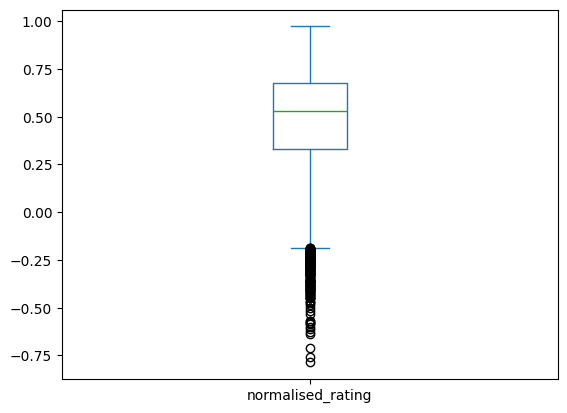

In [117]:
mean_ratings.plot.box()

## 4 Text preprocessing

In [26]:
# Change to lowercase and remove non alphabetical/space characters
def clean_text(text):
    text = text.lower()
    text = re.sub(r'[^a-z\s]', '', text)
    return text

raw_reviews['cleaned_text'] = raw_reviews['text'].progress_apply(clean_text)
clear_output()

In [27]:
# Tokenize text
from nltk.tokenize import word_tokenize

raw_reviews['tokens'] = raw_reviews['cleaned_text'].progress_apply(word_tokenize)
clear_output()

In [28]:
# Remove stopwords
english_stopwords = set(nltk.corpus.stopwords.words('english'))

def remove_stopwords(tokens):
    return [token for token in tokens if token not in english_stopwords]

raw_reviews['no_stopword_tokens'] = raw_reviews['tokens'].progress_apply(remove_stopwords)
clear_output()

## 5 Sentiment analysis

### 5.1 Lexicon scoring

#### 5.1.1 Generate AFINN scores

In [29]:
# Normalised AFINN score
afinn = Afinn()

def normalised_afinn(text):
    afinn_score = afinn.score(text)
    token_count = len(text.split())
    return (afinn_score / token_count) / 5

raw_reviews['afinn_score'] = raw_reviews['cleaned_text'].progress_apply(normalised_afinn)
clear_output()

#### 5.1.1 Assess AFINN scores

In [123]:
afinn_correlation = spearmanr(raw_reviews[['normalised_rating', 'afinn_score']])
print(f'Rating/AFINN correlation:\nCoefficient: {afinn_correlation.statistic}\np value: {afinn_correlation.pvalue}')

Rating/AFINN correlation:
Coefficient: 0.4918743708231228
p value: 0.0


<Axes: >

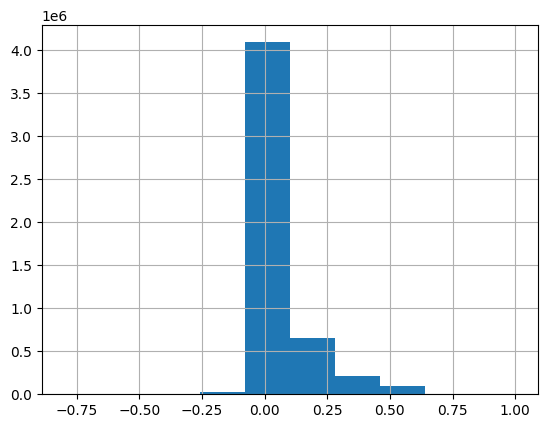

In [30]:
raw_reviews['afinn_score'].hist()

<Axes: >

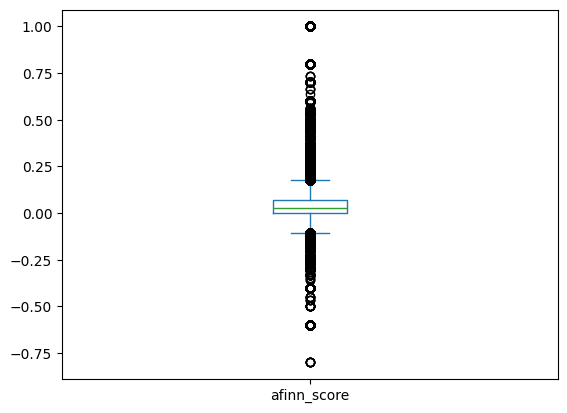

In [31]:
raw_reviews['afinn_score'].plot.box()

In [141]:
# Classify Afinn score
def afinn_classification(score):
    if score >= 0.003:
        return 'Positive'
    elif score <= -0.003:
        return 'Negative'
    else:
        return 'Neutral'

raw_reviews['afinn_classification'] = raw_reviews['afinn_score'].progress_apply(afinn_classification)
clear_output()

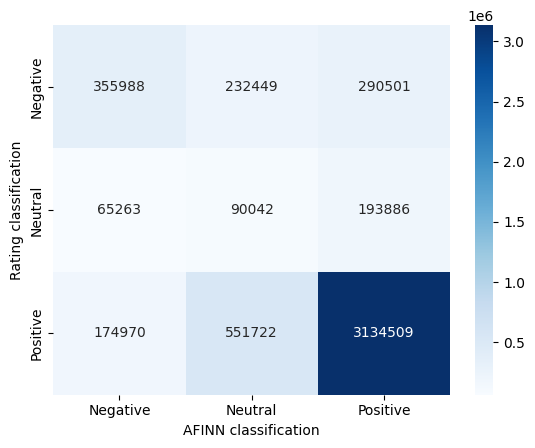

In [140]:
confusion = pd.crosstab(
    raw_reviews['rating_classification'],
    raw_reviews['afinn_classification'],
    rownames=['Rating classification'],
    colnames=['AFINN classification']
)

sns.heatmap(confusion, annot=True, fmt='d', cmap='Blues')
plt.show()

### 5.2 VADER scoring

#### 5.2.1 Generate VADER scores

In [34]:
# Generate VADER score
sia = SentimentIntensityAnalyzer()

def vader_sentiment(text):
    return sia.polarity_scores(text)['compound']

raw_reviews['vader_score'] = raw_reviews['cleaned_text'].progress_apply(vader_sentiment)
clear_output()

#### 5.2.2 Assess VADER scores

In [124]:
vader_correlation = spearmanr(raw_reviews[['normalised_rating', 'vader_score']])
print(f'Rating/AFINN correlation:\nCoefficient: {vader_correlation.statistic}\np value: {vader_correlation.pvalue}')

Rating/AFINN correlation:
Coefficient: 0.460297860016889
p value: 0.0


<Axes: >

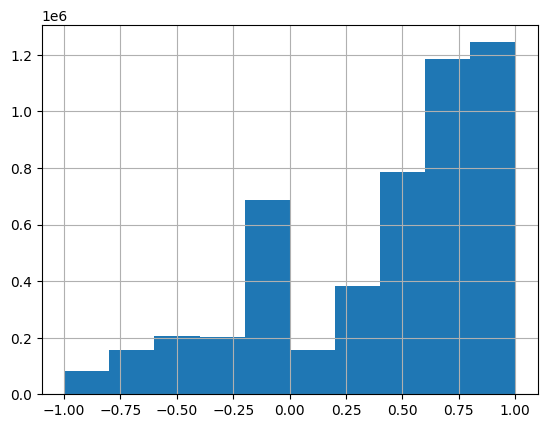

In [114]:
raw_reviews['vader_score'].hist()

<Axes: >

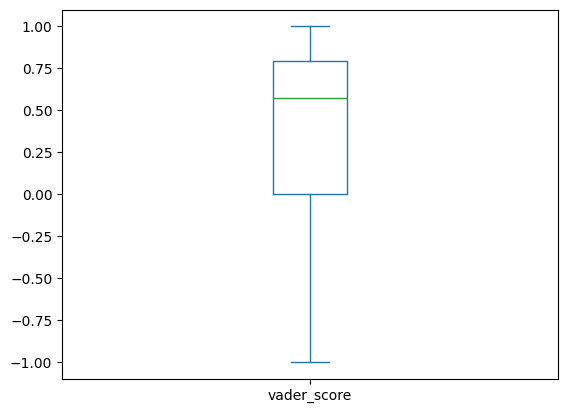

In [113]:
raw_reviews['vader_score'].plot.box()

In [138]:
# Classify VADER score
def vader_classification(score):
    if score >= 0.225:
        return 'Positive'
    elif score <= -0.225:
        return 'Negative'
    else:
        return 'Neutral'

raw_reviews['vader_classification'] = raw_reviews['vader_score'].progress_apply(vader_classification)
clear_output()

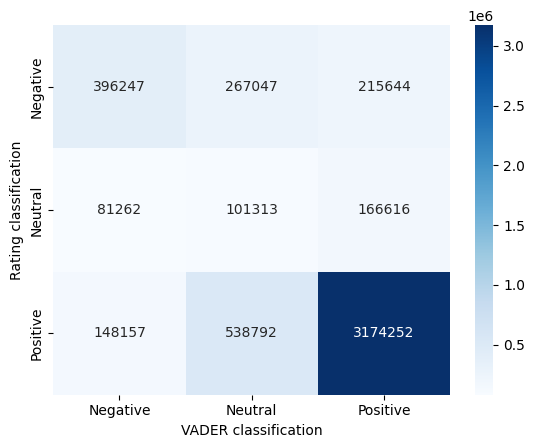

In [139]:
confusion = pd.crosstab(
    raw_reviews['rating_classification'],
    raw_reviews['vader_classification'],
    rownames=['Rating classification'],
    colnames=['VADER classification']
)

sns.heatmap(confusion, annot=True, fmt='d', cmap='Blues')
plt.show()

## 6 Topic classification

### 6.1 Choosing the product

In [56]:
popular_product_reviews = raw_reviews[raw_reviews['asin'] == raw_reviews['asin'].value_counts().index[0]]

<Axes: ylabel='count'>

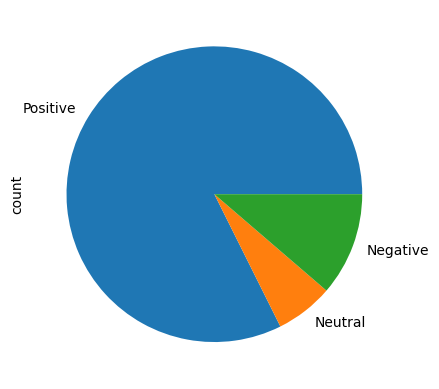

In [57]:
popular_product_reviews['rating_classification'].value_counts().sort_index(ascending=False).plot.pie()

### 6.2 Perform modelling

#### 6.2.1 Positive reviews

##### 6.2.1.1 Modelling

In [75]:
# Set up data for model
positive_reviews = popular_product_reviews[popular_product_reviews['rating_classification'] == 'Positive']
positive_reviews_text_only = positive_reviews['no_stopword_tokens'].apply(lambda x: ' '.join(x))

In [76]:
# Create model
positive_review_topic_model = BERTopic(language='english')

In [77]:
# Run model
positive_review_topic_series, positive_review_probs = positive_review_topic_model.fit_transform(positive_reviews_text_only)

In [78]:
# Get data from model
positive_reviews['topic'] = positive_review_topic_series
positive_review_topics = positive_review_topic_model.get_topic_info().set_index('Topic')

In [112]:
positive_review_topics[['Name', 'Count']][1:26]

,Name,Count
Topic,,
0,0_tailbone_tail_bone_pressure,1369
1,1_car_trips_driving_long,335
2,2_pillow_pillows_love_using,312
3,3_hip_hips_pain_replacement,297
4,4_sciatica_sciatic_nerve_pain,289
5,5_car_height_seat_short,276
6,6_lower_back_pain_low,216
7,7_comfortable_gaming_described_meets,210
8,8_review_foam_everlasting_memory,154


##### 6.2.1.2 Word cloud

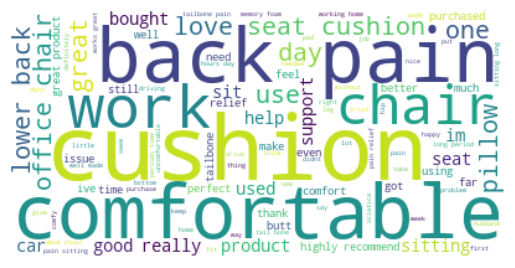

In [104]:
# String with all the words (excl stopwords)
positive_wordcloud = WordCloud(background_color='white', repeat=True).generate(text=' '.join(positive_reviews_text_only))
plt.axis('off')
plt.imshow(positive_wordcloud, interpolation='bilinear')
plt.show()
plt.show()

#### 6.2.2 Negative reviews

##### 6.2.1.2 Modelling

In [58]:
# Set up data for model
negative_reviews = popular_product_reviews[popular_product_reviews['rating_classification'] == 'Negative']
negative_reviews_text_only = negative_reviews['no_stopword_tokens'].apply(lambda x: ' '.join(x))

In [59]:
# Create model
negative_review_topic_model = BERTopic(language='english')

In [62]:
# Run model
negative_review_topic_series, negative_review_probs = negative_review_topic_model.fit_transform(negative_reviews_text_only)

In [63]:
# Get data from model
negative_reviews['topic'] = negative_review_topic_series
negative_review_topics = negative_review_topic_model.get_topic_info().set_index('Topic')

In [111]:
negative_review_topics[['Name', 'Count']][1:26]

,Name,Count
Topic,,
0,0_cushion_seat_uncomfortable_hard,99
1,1_sciatica_sciatic_nerve_pain,84
2,2_tailbone_pain_tail_bone,66
3,3_foam_memory_product_hard,61
4,4_chair_office_uncomfortable_comfortable,54
5,5_legs_circulation_thighs_leg,53
6,6_pillow_use_support_like,52
7,7_pain_relief_help_comfortable,49
8,8_flat_support_weeks_shape,49


##### 6.2.2.2 Word cloud

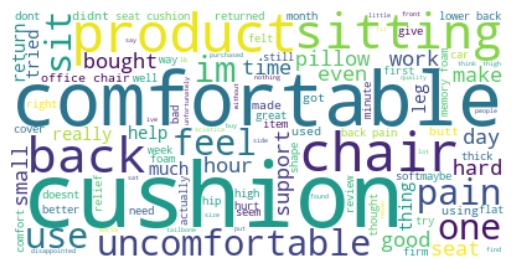

In [105]:
# String with all the words (excl stopwords)
negative_wordcloud = WordCloud(background_color='white', repeat=True).generate(text=' '.join(negative_reviews_text_only))
plt.axis('off')
plt.imshow(negative_wordcloud, interpolation='bilinear')
plt.show()
plt.show()